# **Asignatura**: Aprendizaje Automático

**Práctica 3**: Introducción a Deep Learning

**Valoración máxima**: 10 puntos

**Fecha límite de entrega**: 23 de Mayo de 2026 a las 23:59

**Procedimiento de entrega**: a través de PRADO

### Nombre completo: Jesús Muñoz Velasco



**Normas de desarrollo y entrega de trabajos**

- Única y exclusivamente se debe entregar este Notebook de Colab (fichero `.ipynb`). **No es necesario entregar ninguna memoria externa** (por ejemplo, en `.pdf`).

- El código debe estar bien comentado (explicando lo que realizan los distintos apartados y/o bloques), y todas las decisiones tomadas y el trabajo desarrollado (incluyendo los conceptos fundamentales subyacentes) deben documentarse ampliamente en celdas de texto. Es obligatorio documentar las valoraciones y decisiones adoptadas en el desarrollo de cada uno de los apartados. Debe incluirse también tanto una descripción de las principales funciones (Python/scikit-learn) empleadas (para mostrar que el alumno comprende, a nivel técnico, lo que está haciendo), como una valoración razonada sobre la calidad de los resultados obtenidos. **Sin esta documentación, se considera que el trabajo NO ha sido presentado**.

- La entrega en PRADO está configurada para permitir sucesivas entregas de la práctica. Desde este punto de vista, se recomienda subir versiones de la práctica a medida que se van realizando los distintos ejercicios propuestos, y no dejarlo todo para el final.

- Se debe respetar la estructura y secciones del Notebook. Esto servirá para agilizar las correcciones, así como para identificar con facilidad qué ejercicio/apartado se está respondiendo.

- El código **NO debe escribir nada a disco**.

- El **path de lectura desde Google Drive debe ser siempre el mismo**, que es el que se indica en este Notebook.

- Una entrega es apta para ser corregida si se puede ejecutar de principio a fin sin errores. Es decir, un ejercicio con errores de ejecución tendrá una calificación de 0.

- No es válido usar opciones en las entradas (es decir, utilizar el comando `input()`, por ejemplo, para que el usuario escoja el valor de las variables para ejecutar el programa). Para ello, se deben fijar al comienzo los valores

por defecto que se consideren óptimos o que se soliciten en el enunciado.

- Se entrega solamente este Notebook, y no los datos empleados.


# **Ejercicio 1: Aprendizaje Supervisado (5 puntos)**

## 1.1 Contexto: Análisis de Sentimientos en Reseñas de Cine

En este ejercicio abordaremos un problema clásico de **Procesamiento de Lenguaje Natural (NLP)** utilizando redes neuronales densas (Perceptrón Multicapa).

El objetivo es clasificar reseñas de películas como **Positivas (1)** o **Negativas (0)** basándose en el texto de la crítica.

**Dataset:** IMDB Movie Reviews. Contiene 50.000 reseñas altamente polares. Keras proporciona este dataset preprocesado, donde las palabras ya han sido convertidas a secuencias de enteros (índices en un diccionario).

In [2]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# Carga del dataset IMDB limitado a las 10,000 palabras más frecuentes
(train_data, train_labels), (test_data, test_labels) = keras.datasets.imdb.load_data(num_words=10000)

print(f"Entrenamiento: {len(train_data)} reseñas")
print(f"Test: {len(test_data)} reseñas")

# Ejemplo de una reseña (enteros)
print("Ejemplo de reseña (indices):", train_data[0])

Entrenamiento: 25000 reseñas
Test: 25000 reseñas
Ejemplo de reseña (indices): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5

## 1.2 Tareas a realizar

El alumno debe completar los siguientes apartados:

1.  **Preprocesado de datos (Vectorización):**
    * Las listas de enteros tienen longitudes variables, lo cual no es admisible para una red densa estándar. Debe transformar las listas en tensores de tamaño fijo.
    * **Tarea:** Implemente una función para realizar **One-hot Encoding** (o Multi-hot) que convierta cada reseña en un vector de dimensión 10,000 (donde 1 indica la presencia de la palabra y 0 su ausencia).
    * Vectorice tanto los datos de train como los de test.

2.  **Construcción del Modelo:**
    * Diseñe una red neuronal secuencial (`tf.keras.Sequential`).
    * Use 2 o 3 capas densas (`Dense`).
    * Use funciones de activación `relu` para las capas ocultas.
    * **Importante:** La capa de salida debe tener 1 sola neurona con activación `sigmoid` (para clasificación binaria).

3.  **Compilación y Entrenamiento:**
    * Optimizador: `rmsprop` o `adam`.
    * Función de pérdida: `binary_crossentropy`.
    * Métrica: `accuracy`.
    * Separe una parte de los datos de entrenamiento para validación.
    * Entrene durante 20 épocas.

4.  **Evaluación:**
    * Muestre la gráfica la evolución de la pérdida (`loss`) y la precisión (`accuracy`) tanto en entrenamiento como en validación.
    * Evalúe el modelo final sobre el conjunto de test.

### 1.2.1. Preprocesado de datos (vectorización)

Dado que necesitamos una dimensión de entrada fija y estructurada para una red neuronal densa y los datos vienen estructurados como una lista de enteros (que representan los índices de ciertas palabras en un diccionario) necesitamos convertir cada lista en un vector binario (de dimensión 10,000) de la siguiente forma: si la palabra con índice $i$ aparece en la reseña, la posición $i$ del vector se marca con un 1.0; de lo contrario, se mantiene en 0.0. Esto lo haremos con `vectorize_sequences`.

In [3]:
dim = 10000

def vectorize_sequences(sequences, dimension=dim):
    # Creamos una matriz de ceros con dimensiones (número de reseñas, dimensión del diccionario)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        # Colocamos un 1.0 en los índices de las palabras presentes en la reseña
        results[i, sequence] = 1.0
    return results

# Vectorizamos los datos de entrenamiento y de test
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

# Conversión de las etiquetas a vectores numéricos tipo float32
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

# Separación de un conjunto de validación (10,000 muestras)
x_val = x_train[:dim]
partial_x_train = x_train[dim:]
y_val = y_train[:10000]
partial_y_train = y_train[dim:]

### 1.2.2. Construcción del modelo

Siguiendo la estructura especificada en el enunciado se ha creado el modelo. Además, se ha elegido usar dos capas `Dense`, ya que esta configuración proporciona la capacidad representacional necesaria para separar las fronteras de decisión sin sobredimensionar el espacio de parámetros, reduciendo el riesgo de sobreajuste temprano.

In [11]:
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense

model= Sequential()

# Capa de entrada
model.add( Input(shape=(x_train.shape[1],)))

# Capa oculta 1: 16 neuronas con activación ReLU
model.add( Dense(16, activation='relu') )

# Capa oculta 2: 16 neuronas con activación ReLU
model.add( Dense(16, activation='relu') )

# Capa de salida: 1 neurona con activación Sigmoide para clasificación binaria
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

### 1.2.3. Compilación y entrenamiento

Siguiendo con las especificaciones del enunciado se ha compilado y entrenado el modelo. Se ha elegido el compilador `rmprop` por ser la opción estándard para este tipo de arquitecturas.

In [12]:
# Compilación
model.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Entrenamiento
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 152ms/step - accuracy: 0.7382 - loss: 0.5886 - val_accuracy: 0.7822 - val_loss: 0.4945
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.8820 - loss: 0.3946 - val_accuracy: 0.8737 - val_loss: 0.3659
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9082 - loss: 0.2934 - val_accuracy: 0.8874 - val_loss: 0.3083
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9231 - loss: 0.2378 - val_accuracy: 0.8902 - val_loss: 0.2875
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9363 - loss: 0.1979 - val_accuracy: 0.8888 - val_loss: 0.2789
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9446 - loss: 0.1710 - val_accuracy: 0.8825 - val_loss: 0.2877
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9526 - loss: 0.1485 - val_accuracy: 0.8865 - val_loss: 0.2851
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9588 - loss: 0.1296 - val_accuracy: 0.8841 - 

### 1.2.4. Evaluación

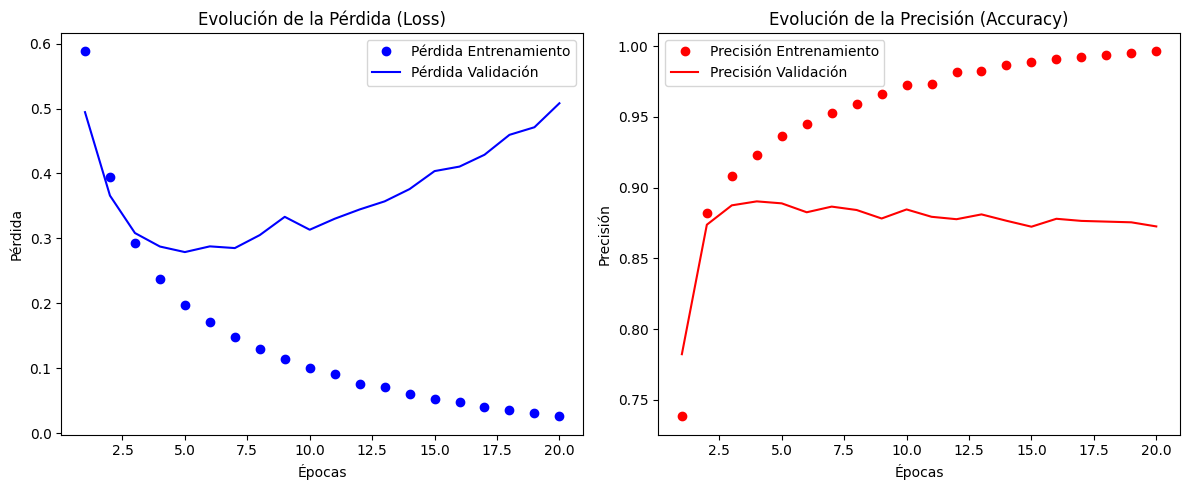


Resultados finales sobre el conjunto de TEST:
 -> Pérdida (Loss) en Test: 0.5442
 -> Precisión (Accuracy) en Test: 0.8615


In [13]:
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
epochs = range(1, len(loss_values) + 1)

# Gráfica de Pérdida (Loss)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, loss_values, 'bo', label='Pérdida Entrenamiento')
plt.plot(epochs, val_loss_values, 'b', label='Pérdida Validación')
plt.title('Evolución de la Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

# Gráfica de Precisión (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(epochs, acc, 'ro', label='Precisión Entrenamiento')
plt.plot(epochs, val_acc, 'r', label='Precisión Validación')
plt.title('Evolución de la Precisión (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.tight_layout()
plt.show()

# Evaluación final en el conjunto de test independiente
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nResultados finales sobre el conjunto de TEST:")
print(f" -> Pérdida (Loss) en Test: {test_loss:.4f}")
print(f" -> Precisión (Accuracy) en Test: {test_acc:.4f}")

Al observar las gráficas generadas tras las 20 épocas, se aprecia un comportamiento de sobreajuste (overfitting):

Se puede ver que la pérdida en entrenamiento va tendiendo a valores cercanos a cero, y la precisión en entrenamiento roza el 100%.

Sin embargo, la pérdida de validación alcanza su punto óptimo alrededor de la época 4 o 5 y, a partir de ahí, comienza a ascender drásticamente. De igual forma, en la validación se puede ver que la precisión es ligeramente mejor en la época 4 o 5 aunque no se nota tanto perjuicio (manteniendose entre el rango 85%-90%).

Conclusión: El modelo empieza a memorizar el ruido y las particularidades del conjunto de entrenamiento en lugar de generalizar. Si quisiéramos mejorar el rendimiento final en test (que suele rondar el ~85-87% de accuracy), la decisión de ingeniería óptima sería aplicar técnicas de regularización (como Dropout o regularización L2) o implementar una estrategia de Early Stopping para detener el entrenamiento en la época 4.

---

# **Ejercicio 2: Aprendizaje No Supervisado (5 puntos)**

## 2.1 Contexto: Eliminación de Ruido en Imágenes (Denoising Autoencoder)

En este ejercicio utilizaremos una arquitectura de tipo **Autoencoder Convolucional** para una tarea de aprendizaje no supervisado: la restauración de imágenes.

El objetivo no es clasificar qué número hay en la imagen, sino aprender a **limpiar** una imagen que ha sido corrompida por ruido aleatorio.

**Dataset:** MNIST (Dígitos manuscritos). Nosotros introduciremos el ruido artificialmente.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


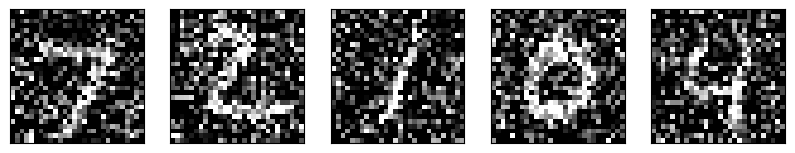

In [14]:
# Carga y normalización de MNIST
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalización [0, 1] y reshape a (28, 28, 1)
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# Función para añadir ruido aleatorio
def add_noise(images, noise_factor=0.5):
    noisy_imgs = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    return np.clip(noisy_imgs, 0., 1.)

x_train_noisy = add_noise(x_train)
x_test_noisy = add_noise(x_test)

# Visualización del ruido
n = 5
plt.figure(figsize=(10, 2))
for i in range(n):
    ax = plt.subplot(1, n, i + 1)
    plt.imshow(tf.squeeze(x_test_noisy[i]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

## 2.2 Tareas a realizar

1.  **Construcción del Autoencoder:**
    * Debe construir un modelo que tenga dos partes: **Encoder** y **Decoder**.
    * **Encoder:** Use capas `Conv2D` y `MaxPooling2D` para comprimir la imagen.
    * **Decoder:** Use capas `Conv2D` y `UpSampling2D` (o `Conv2DTranspose`) para reconstruir la imagen al tamaño original (28x28).
    * La capa de salida debe tener 1 filtro y activación `sigmoid` (para que los píxeles estén entre 0 y 1).

2.  **Entrenamiento:**
    * **Entrada (X):** Imágenes con ruido (`x_train_noisy`).
    * **Objetivo (Y):** Imágenes originales limpias (`x_train`).
    * Pérdida: `binary_crossentropy` (funciona bien píxel a píxel) o `mse`.
    * Entrene por al menos 10 épocas.

3.  **Resultados:**
    * Utilice el modelo entrenado para limpiar las imágenes de test (`x_test_noisy`).
    * Visualice una comparativa: **Original** | **Ruidosa** | **Reconstruida** para al menos 5 ejemplos.

### 2.2.1. Construcción del Autoencoder

Un Autoencoder para eliminación de ruido fundamenta su funcionamiento en forzar a la información a pasar por una restricción de la dimensión (cuello de botella o bottleneck) para aprender las estructuras más importantes de los datos, descartando el ruido. Seguiré la siguiente estructura:

- **Encoder (Compresión)**: Utilizaremos capas `Conv2D` combinadas con `MaxPooling2D`. Las capas convolucionales aplican filtros para extraer patrones geométricos (bordes, trazos numéricos). `MaxPooling2D` reduce el tamaño espacial de las imágenes a la mitad en cada paso ($28 \times 28 \to 14 \times 14 \to 7 \times 7$), forzando a la red a retener únicamente una representación abstracta, compacta y densa de los dígitos.

- **Decoder (Reconstrucción)**: Realiza el proceso inverso. Mediante capas `UpSampling2D`, se duplica el tamaño espacial de la representación intermedia ($7 \times 7 \to 14 \times 14 \to 28 \times 28$) mapeando las características esenciales de vuelta al espacio de píxeles original.

- **Capa de Salida**: Emplea una última convolución con un único filtro y activación Sigmoide. Al igual que en la normalización previa de `MNIST`, esto asegura matemáticamente que los valores de intensidad de cada píxel reconstruido estén confinados entre 0.0 (negro absoluto) y 1.0 (blanco absoluto).

In [15]:
from tensorflow.keras import layers, models

# Definición del modelo
input_img = layers.Input(shape=(28, 28, 1))

# ENCODER
# Primera etapa convolucional: Extrae características espaciales de bajo nivel
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x) # Reduce dimensiones a (14, 14, 32)
# Segunda etapa convolucional: Extrae características abstractas comprimidas
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x) # Cuello de botella: (7, 7, 32)

# DECODER
# Primera etapa de reconstrucción: Expande las dimensiones espaciales
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x) # Aumenta dimensiones a (14, 14, 32)
# Segunda etapa de reconstrucción
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x) # Aumenta dimensiones a (28, 28, 32)

# SALIDA
# Capa de salida convolucional: Proyecta los canales de vuelta a 1 (imagen en escala de grises)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Instanciación y compilación del modelo global
autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Visualización del resumen estructural de la red
autoencoder.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

### 2.2.2. Entrenamiento

Se entrenó usando el optimizador `adam` y la función de pérdida `binary_crossentropy`. Aunque estemos reconstruyendo imágenes continuas, esta función de pérdida funciona muy bien píxel a píxel si estos están normalizados en $[0, 1]$, penalizando severamente los errores estructurales.

In [16]:
history_ae = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    verbose=1
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 129s 264ms/step - loss: 0.1705 - val_loss: 0.1181
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 262ms/step - loss: 0.1144 - val_loss: 0.1098
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 123s 263ms/step - loss: 0.1087 - val_loss: 0.1056
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 144s 268ms/step - loss: 0.1053 - val_loss: 0.1035
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 150s 285ms/step - loss: 0.1031 - val_loss: 0.1015
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 134s 286ms/step - loss: 0.1017 - val_loss: 0.1000
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 287ms/step - loss: 0.1006 - val_loss: 0.0995
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 136s 274ms/step - loss: 0.0998 - val_loss: 0.0992
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 130s 276ms/step - loss: 0.0991 - val_loss: 0.0984
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 136s 290ms/step - loss: 0.0986 - val_loss: 0.0977


### 2.2.3. Resultados

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step


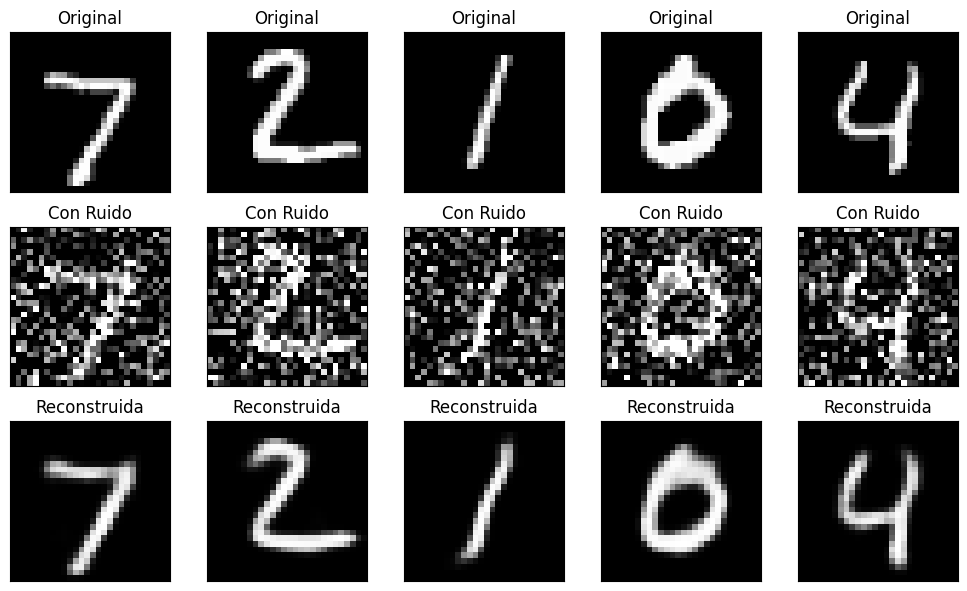

In [17]:
# Predecimos la reconstrucción limpia sobre el conjunto de test ruidoso
decoded_imgs = autoencoder.predict(x_test_noisy)

n = 5  # Número de ejemplos a mostrar
plt.figure(figsize=(10, 6))
for i in range(n):
    # Fila 1: Imágenes Originales Limpias
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(tf.squeeze(x_test[i]), cmap='gray')
    plt.title("Original")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Fila 2: Imágenes con Ruido (Entrada al Autoencoder)
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(tf.squeeze(x_test_noisy[i]), cmap='gray')
    plt.title("Con Ruido")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Fila 3: Imágenes Reconstruidas (Salida del Autoencoder)
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(tf.squeeze(decoded_imgs[i]), cmap='gray')
    plt.title("Reconstruida")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()

El rendimiento del modelo es increíblemente bueno. En la visualización comparativa de tres filas, se puede ver que las imágenes de la fila "Con Ruido" presentan anomalías y discontinuidades (hay muchos píxeles que no tienen sentido).
Sin embargo, la fila "Reconstruida" devuelve los dígitos con trazos continuos, formas suaves y fondos homogéneamente negros. El autoencoder ha logrado "entender" los trazos que constituyen un dígito manuscrito válido, filtrando de forma efectiva el ruido aleatorio introducido artificialmente.

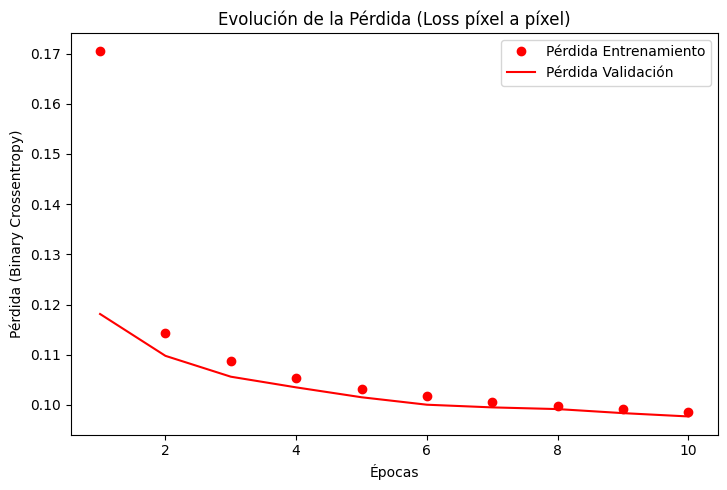

In [21]:
history_dict = history_ae.history
epochs = range(1, len(history_dict['loss']) + 1)

# Gráfica de la Pérdida (Loss)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history_dict['loss'], 'ro', label='Pérdida Entrenamiento')
plt.plot(epochs, history_dict['val_loss'], 'r', label='Pérdida Validación')
plt.title('Evolución de la Pérdida (Loss píxel a píxel)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (Binary Crossentropy)')
plt.legend()

plt.tight_layout()
plt.show()

Se puede ver que ahora la pérdida sí sigue descendiendo hasta valores muy cercanos a cero, lo que le da a nuestro modelo un extra de confianza (e indica que no tiene sobreajuste).

---

# **Conclusiones Generales**

Añada una celda de texto final comentando las diferencias fundamentales que ha observado en la forma de entrenar un modelo supervisado (donde le damos una etiqueta de clase) frente al no supervisado (donde la propia imagen limpia actúa como supervisor).

oA lo largo de esta práctica, se han puesto de manifiesto diferencias fundamentales en las técnicas de entrenamiento, objetivos matemáticos y dinámicas de aprendizaje entre ambos enfoques:

1. **Naturaleza de la Información de Guía (Supervisión)**
- En el Modelo Supervisado, el aprendizaje está guiado por una señal semántica externa y abstracta (las etiquetas categóricas 0 o 1). El modelo intenta forzar la reducción de un espacio de una dimensión muy alta (vectores de palabras) a una única variable escalar que representa un concepto abstracto humano (sentimiento).

- En el Modelo No Supervisado, no existen etiquetas externas. La propia imagen limpia de origen actúa como su supervisor matemático directo. El modelo realiza un mapeo de la estructura consigo misma ($X \to Z \to X'$), donde el objetivo no es categorizar, sino reconstruir y preservar la topología de los datos originales.

2. **Comportamiento frente al Sobreajuste (Overfitting)**

- El modelo supervisado es altamente sensible al sobreajuste: si entrena en exceso, memoriza combinaciones de palabras específicas de las reseñas de entrenamiento que no se repiten en el test, provocando que la pérdida de validación diverja rápidamente, como se ha visto en las gráficas finales del ejercicio 1.

- El autoencoder, debido a la restricción física del cuello de botella arquitectónico (bottleneck), es más robusto. Al no poder almacenar toda la matriz de píxeles textualmente en su capa intermedia comprimida, se ve obligado a aprender la función de distribución general de las imágenes. Por ello, la pérdida de validación va tendiendo a 0, de igual forma que en el entrenamiento, tal y como se puede ver en la gráfica final del ejercicio 2.

3. **Extracción de Características (Feature Extraction)**

- El aprendizaje supervisado genera características orientadas exclusivamente a maximizar el margen de separación entre clases (discriminativo).

- El aprendizaje no supervisado mediante autoencoders extrae características generativas y estructurales, capaces de capturar la esencia geométrica interna de los datos, permitiendo restaurar información corrupta.